# Introduction to control theory. 

## TP5. State Observers. LQ.
## Study load

Course grade breakdown:

    Labs - 40%
    
    Final project presentation 30%

    Final test 30%
    
File name for lab submission: yourname_labnumber.ipynb (example: elenavanneaux_TP4.ipynb)    

The completed notebook should be **submitted via the corresponding Moodle assignment before the beginning of the next session.**

## Prerequisites for practice
### Math
During the course, we will cover the following areas of mathematics:
    
    1. Linear Algebra

    2. Calculus

    3. Differential equations

    4. Dynamics (Mechanics and Physics)

### Python programming
In the labs we will use a Python programming language and the following libraries:

    1. NumPy https://numpy.org/doc/stable/

    2. SciPy https://docs.scipy.org/doc/scipy/

    3. Matplotlib https://matplotlib.org/stable/tutorials/index

    4. SymPy https://docs.sympy.org/latest/tutorials/intro-tutorial/intro.html

    5. Control System Library https://python-control.readthedocs.io/en/0.10.1/intro.html

### Jupyter Notebook Markdown Cells Documentation

Please check on Markdown cells documentation, to provide a fancy look for your notebooks!

https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html




## TODO

Last time you designed a full-state feedback controller $u=-Kx, $ which stabilizes the system in steady state
$x = (0,0,0,0).$

0. If you have not done this - do it today! And don't hesitate to ask questions if it is unclear.

This time let us assume that we only measure the position and the angular velocity, while their derivatives are not availabe. I.e. $y_{output} = (y, \theta)' = Cx,$ where 
$$C = \begin{pmatrix} 1 & 0 & 0 &0 \\ 0 & 0 & 1 &0 \end{pmatrix}$$

Considering: 

$$\left[\begin{array}{c}\dot{y} \\ \dot{y1} \\ \dot{\theta} \\ \dot{\theta_1}\end{array}\right]=
\left[\begin{array}{cccc}0 & 1 & 0 & 0 \\
0 & \frac{-\left(I+m l^2\right) b}{I(M+m)+M m l^2}& \frac{-g m^2 l^2}{I(M+m)+M m l^2} & 0 \\
0 & 0 & 0 & 1 \\
0 & \frac{m l b}{I(M+m)+M m l^2} & \frac{m g l(M+m)}{I(M+m)+M m l^2} & 0\end{array}\right]
\left[\begin{array}{c}y \\ y_1\\ \theta \\ \theta_1\end{array}\right]+
\left[\begin{array}{c}0 \\ \frac{I+m l^2}{I(M+m)+M m l^2} \\ 0\\ \frac{-m l}{I(M+m)+M m l^2}\end{array}\right] (u+w)$$

1. Is the pair of matrices (A,C) observable? Why is this important? 

2. For an autonomous system
$$
\dot x = Ax, \ y = Cx
$$

design an observer $$\dot{\hat{x}} = (A - LC)\hat{x} + Ly,$$ such that the estimation of the state $\hat{x}$ converges to real state $x$. To do that, we need to find a matrice $L$ such that the matrice $A-LC$ is Hurwitz (i.e., all its eigenvalues have a negative real part). 

**Remark:** to place arbitary eigenvalues $\lambda_1,\ldots \lambda_n$ in matrice (A - LC) with matrice L, it is the same as to place $\lambda_1,\ldots \lambda_n$ in matrice $(A^T - C^TL^T)$ with matrice $L^T$. 

Plot a real trajectory $x$ starting from the point $x_0 = (2,0,1,0)$ and its estimation $\hat{x}$ starting from the point $\hat{x}_0 = (3,-1,2,0.5)$ to show convergence.

3. Design an optimal estimator (LQE) and an optimal estimated-state-feedback controller (LQR), which stabilizes the system in (0,0,0,0).

**Remark:** See slide "observer and controller" in the lecture.

In [5]:
import numpy as np
import control as ctr

M = 0.5  # mass of the cart
m = 0.2  # mass of the pendulum
l = 0.3  # length to pendulum center of mass
b = 0.1  # coefficient of friction for cart
I = 0.006  # mass moment of inertia of the pendulum
g = 9.81  # gravity

den = I * (M + m) + M * m * l**2

A = np.array([
    [0, 1, 0, 0],
    [0, -((I + m * l**2) * b) / den, -(g * m**2 * l**2) / den, 0],
    [0, 0, 0, 1],
    [0, (m * l * b) / den, (m * g * l * (M + m)) / den, 0],
], dtype=float)

C = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
], dtype=float)

n = A.shape[0]
# 1) observability matrix O = [ C ; C A ; C A^2 ; ... ; C A^(n-1) ]
O_blocks = []
A_power = np.eye(n)  # A^0
for _k in range(n):
    O_blocks.append(C @ A_power)
    A_power = A_power @ A
O = np.vstack(O_blocks)

print("Observability matrix O (shape {}):".format(O.shape))
print(O)

# 2) Simple rank test: (A, C) is observable iff rank(O) = n
rankO = np.linalg.matrix_rank(O)
obs = (rankO == n)

print("rank(O) =", rankO, "| n =", n)
print("(A, C) observable?", obs)


Observability matrix O (shape (8, 4)):
[[ 1.          0.          0.          0.        ]
 [ 0.          0.          1.          0.        ]
 [ 0.          1.          0.          0.        ]
 [ 0.          0.          0.          1.        ]
 [ 0.         -0.18181818 -2.67545455  0.        ]
 [ 0.          0.45454545 31.21363636  0.        ]
 [ 0.          0.03305785  0.48644628 -2.67545455]
 [ 0.         -0.08264463 -1.2161157  31.21363636]]
rank(O) = 4 | n = 4
(A, C) observable? True


L shape: (4, 2)
eig(A - L C) = [-2.  -3.5 -2.5 -3. ]
Hurwitz? True


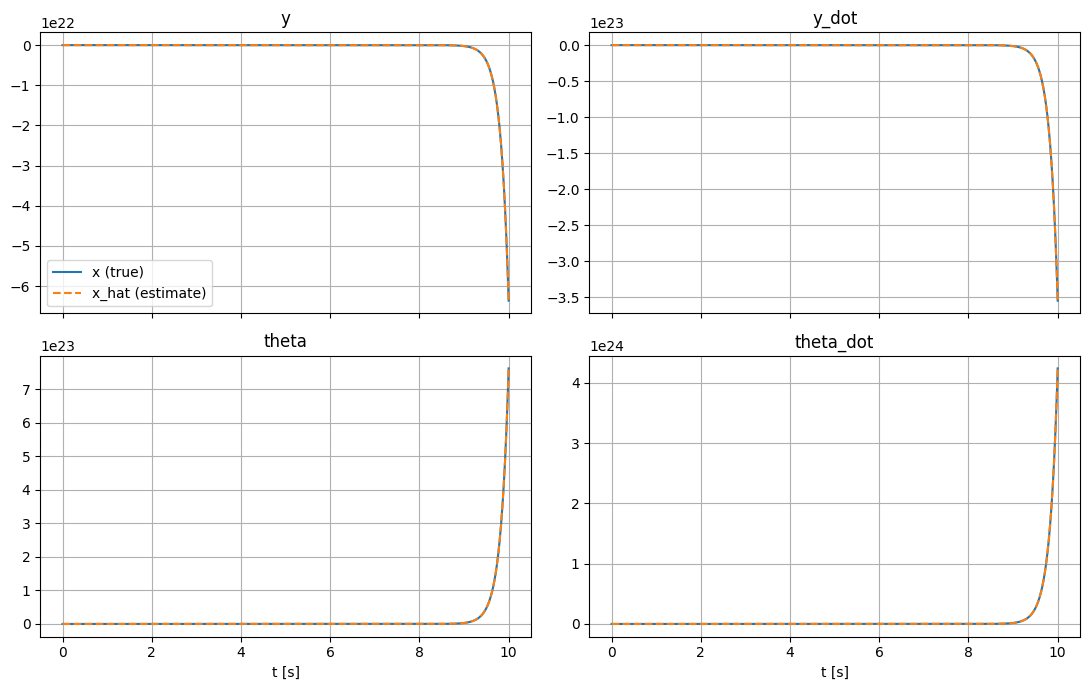

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import control as ctr

# Observer design: xhat_dot = (A - L C) xhat + L y, with y = C x
n = A.shape[0]


# According to Hurwitz stability theory -> all eigenvalues of (A - L C) must have strictly negative real parts.
# Therefore, we choose desired poles in the left-half complex plane so the estimation error dynamic decays to zero.
#Poles aleatory:
desired_poles = np.array([-2.0, -2.5, -3.0, -3.5])

#Definition of the observer gain L:
# Place poles for the dual system: (A^T, C^T), then transpose back.
L = ctr.place(A.T, C.T, desired_poles).T
print("L shape:", L.shape)

# Check eigenvalues of (A - L C) to confirm stability
Acl = A - L @ C
eig_Acl = np.linalg.eigvals(Acl)
print("eig(A - L C) =", eig_Acl)
print("Hurwitz?", np.all(np.real(eig_Acl) < 0))

# ---- Simulation ----
x0 = np.array([2.0, 0.0, 1.0, 0.0])
xhat0 = np.array([3.0, -1.0, 2.0, 0.5])
z0 = np.concatenate([x0, xhat0])  # augmented state [x; xhat]

t0, tf = 0.0, 10.0
t_eval = np.linspace(t0, tf, 1001)

def augmented_dynamics(t, z):
    x = z[:n]
    xhat = z[n:]
    y = C @ x
    x_dot = A @ x
    xhat_dot = (A - L @ C) @ xhat + L @ y
    return np.concatenate([x_dot, xhat_dot])

sol = solve_ivp(augmented_dynamics, (t0, tf), z0, t_eval=t_eval, rtol=1e-8, atol=1e-10)

t = sol.t
x = sol.y[:n, :].T
xhat = sol.y[n:, :].T
err = x - xhat

# ---- Plots: x vs xhat ----
state_labels = ["y", "y_dot", "theta", "theta_dot"]
fig, axs = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
axs = axs.ravel()
for i in range(n):
    axs[i].plot(t, x[:, i], label="x (true)")
    axs[i].plot(t, xhat[:, i], "--", label="x_hat (estimate)")
    axs[i].set_title(state_labels[i])
    axs[i].grid(True)
axs[0].legend(loc="best")
axs[2].set_xlabel("t [s]")
axs[3].set_xlabel("t [s]")
plt.tight_layout()
plt.show()

The plots in Cell 4 show the real state x and its estimate x_hat generated by the observer. Here, y represents the cart position, y_dot its velocity, theta the pendulum angle, and theta_dot the angular velocity. The blue and orange curves stay close to each other, which means that the observer is able to reconstruct the state accurately from the measured outputs. However, all states grow very large with time, showing that the plant itself is unstable in open loop. This happens because the observer does not stabilize the system; its role is only to estimate the unmeasured states.

B shape: (4, 1)
K shape: (1, 4)
eig(A - B K) = [-16.88328593+0.j          -2.29506139+1.58192249j
  -2.29506139-1.58192249j  -3.39922818+0.j        ]
A-BK stable? True
L_kf shape: (4, 2)
eig(A - L_kf C) = [-1.4795216 +1.39210533j -1.4795216 -1.39210533j -5.70732063+1.26268381j
 -5.70732063-1.26268381j]
A-LC Hurwitz? True
eig(A_aug) = [-16.88328593+0.j          -1.4795216 +1.39210533j
  -1.4795216 -1.39210533j  -2.29506139+1.58192249j
  -2.29506139-1.58192249j  -3.39922818+0.j
  -5.70732063+1.26268381j  -5.70732063-1.26268381j]
Augmented stable? True


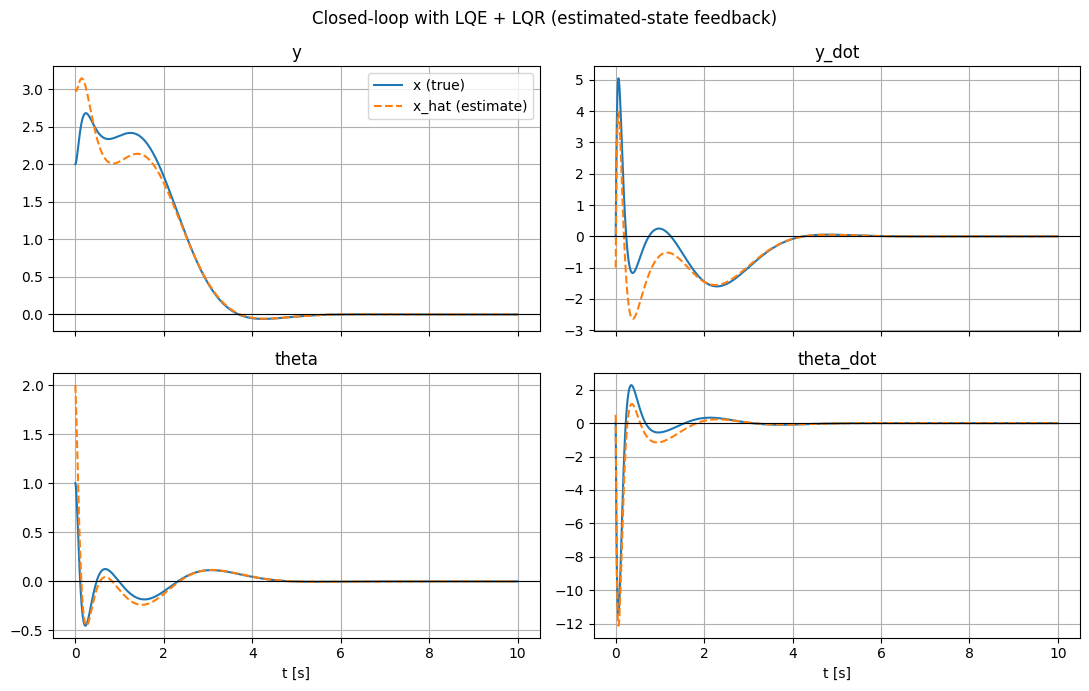

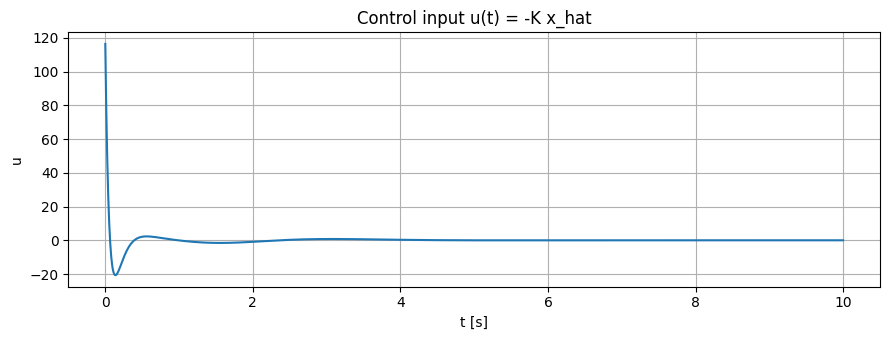

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import control as ctr


# x_dot = A x + B (u + w),   y = C x
n = A.shape[0]

# Build B from the formula in the TP 
B = np.array([
    [0.0],
    [(I + m * l**2) / den],
    [0.0],
    [-(m * l) / den],
], dtype=float)
print("B shape:", B.shape)


# 1) LQR: optimal state feedback u = -K x 

# Cost: integral (x^T Q x + u^T R u) dt
Q = np.diag([10.0, 1.0, 10.0, 1.0])
R = np.array([[0.1]])

K, S, eig_A_BK = ctr.lqr(A, B, Q, R)
K = np.asarray(K)  # ensure ndarray
print("K shape:", K.shape)
print("eig(A - B K) =", eig_A_BK)
print("A-BK stable?", np.all(np.real(eig_A_BK) < 0))

# -------------------------
# 2) LQE (continuous-time Kalman filter): optimal estimator gain L_kf

G = B

# Covariances (tuning knobs): larger Qn -> trust model less / follow measurements more; larger Rn -> trust sensor less.
Qn = np.array([[1e-2]])          # process noise covariance (scalar, because w is scalar)
Rn = 1e-3 * np.eye(C.shape[0])   # measurement noise covariance (2x2)

L_kf, P, eig_A_LC = ctr.lqe(A, G, C, Qn, Rn)
L_kf = np.asarray(L_kf)
print("L_kf shape:", L_kf.shape)
print("eig(A - L_kf C) =", eig_A_LC)
print("A-LC Hurwitz?", np.all(np.real(eig_A_LC) < 0))

# Separation principle check: augmented closed-loop dynamics should be stable
A_aug = np.block([
    [A,             -B @ K],
    [L_kf @ C,  A - B @ K - L_kf @ C],
])
eig_aug = np.linalg.eigvals(A_aug)
print("eig(A_aug) =", eig_aug)
print("Augmented stable?", np.all(np.real(eig_aug) < 0))


# 3) Simulate closed-loop with estimated-state feedback u = -K x_hat

x0 = np.array([2.0, 0.0, 1.0, 0.0])
xhat0 = np.array([3.0, -1.0, 2.0, 0.5])
z0 = np.concatenate([x0, xhat0])

t0, tf = 0.0, 10.0
t_eval = np.linspace(t0, tf, 1501)

def closed_loop_dynamics(t, z):
    x = z[:n]
    xhat = z[n:]
    y = C @ x
    u = -(K @ xhat).item()  # scalar control
    x_dot = (A @ x) + (B.flatten() * u)
    xhat_dot = (A @ xhat) + (B.flatten() * u) + (L_kf @ (y - C @ xhat))
    return np.concatenate([x_dot, xhat_dot])

sol = solve_ivp(closed_loop_dynamics, (t0, tf), z0, t_eval=t_eval, rtol=1e-8, atol=1e-10)

t = sol.t
x = sol.y[:n, :].T
xhat = sol.y[n:, :].T

# Recompute u(t) for plotting
u = np.array([-(K @ xhat_i).item() for xhat_i in xhat])

state_labels = ["y", "y_dot", "theta", "theta_dot"]
fig, axs = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
axs = axs.ravel()
for i in range(n):
    axs[i].plot(t, x[:, i], label="x (true)")
    axs[i].plot(t, xhat[:, i], "--", label="x_hat (estimate)")
    axs[i].axhline(0.0, color="k", linewidth=0.8)
    axs[i].set_title(state_labels[i])
    axs[i].grid(True)
axs[0].legend(loc="best")
axs[2].set_xlabel("t [s]")
axs[3].set_xlabel("t [s]")
plt.suptitle("Closed-loop with LQE + LQR (estimated-state feedback)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 3.5))
plt.plot(t, u)
plt.grid(True)
plt.title("Control input u(t) = -K x_hat")
plt.xlabel("t [s]")
plt.ylabel("u")
plt.tight_layout()
plt.show()